##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]


---

## 0. Iteration setup

**Import libraries**

In [5]:
# CODE CELL: import the necessary libraries for this iteration
# setup the venv by [venv\Scripts\activate]

import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

**Load dataset(s)**

In [6]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_ships = pd.read_csv("ships_inventory_iter1.csv");
# sample is used to see proof of loading the correct dataset and to see if the data gets correcty loaded
df_ships.sample(10)

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
231218,7306999332,7266,7509.0,General Mining Corp,Mimban Swamp
123889,7311778678,18750,7517.0,Kuat Drive Yards,Mimban Swamp
246303,7310507588,34500,7514.0,Kuat Drive Yards,Calodan Expanse
102525,7313598062,14222,7512.0,GALACTIC MOTORS,Onderon Wilds
242846,7316589036,45995,7512.0,Republic Aerospace,Coruscant Core
206415,7302490822,23590,7516.0,Independent Shipwrights,Florrum Badlands
2616,7314450032,18400,7518.0,Independent Shipwrights,Hoth System
24552,7316580142,11000,7506.0,Independent Shipwrights,New Yavin
209985,7310816298,17500,7518.0,Kuat Drive Yards,Nova Corps Base
217008,7311234941,52995,7515.0,Corellian Engineering,Nar Shaddaa Moon


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

#### **Situation Description**

Nebula Brokerage wants to update their current strategy of determining the asking prices for their spaceships. Their dealers currently determine pricing using "gut feelings" and averages. The company is losing credits because of this strategy and have realized this is a risk. Two main reasons have already been identified:

**"Underpricing":** The worth of rare and valuable ships are not being properly recognized, causing them to be sold for less money them they could have potentially earned.

**"Overpricing":** The worth of common ships are being overestimated, causing them to stay in storage because customers are unwilling to pay the high price.

#### **Business Objective(s)**

The goal of this notebook is to establish an accurate data-driven baseline which can be used as a standard reference. Why is this needed in the first place?

The baseline can be used as a reference to determine a "first guess" price for any incoming ships that have not been given a proper look yet. it gives some data to cling onto when no further information is available. Furthemore, this baseline is needed as a comparison for future work. When more complex models are being developed, a baseline is perfect to establish if the model if an actual improvement in the guessing of prices, or if more work needs to be done.

#### **Data Mining Goal(s)**

This is a supervised learning modeling task. The data is labeled and we are trying to make predictions within existing data columns. We know what we are trying to achieve, a baseline model for the "Galactic_Credits" column.

this is also a regression task. The "Galactic_Credits column uses a wide variety of numbers that wouldn't be fit for classification.

#### **Success Criteria**

To make sure the created benchmark is at least accurate to some degree, we will define a succes criteria based on MAE, MSE as well as RMSE. The difference in these metrics will hopefully ensure a better understaning on where the benchmark suceeds and where it falls short. The baseline will be considered a success if it can fulfill the following criteria:

**MAE:**

**MSE:**

**RMSE:**

The goals for these criteria were chosen somewhat arbitrarily, but should give a good sense if the baseline preforms as needed.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [4]:
# CODE CELL: Show basic statistics and information
df_ships.info()
df_ships.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  object 
 4   Sector             368814 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 14.1+ MB


,count,mean,std,min,25%,50%,75%,max
Ship_ID,368814.0,7.311485e+09,4.381124e+06,7.301583e+09,7.308105e+09,7.312604e+09,7.315245e+09,7.317101e+09
Galactic_Credits,368814.0,1.945354e+04,1.554047e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,361408.0,7.511265e+03,9.078571e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03


Observation:

The dataset contains 368,814 ships with information on their cost (Galactic_Credits), model age (Model_Cycle), manufacturer, and sector. Most ships have complete data, except Model_Cycle, which has a small number of missing values. The data includes both numeric (Ship_ID, Galactic_Credits, Model_Cycle) and categorical features (Ship_Manufacturer, Sector), making it suitable for exploring patterns like which manufacturers produce the most expensive ships or which sectors have the most ships.

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

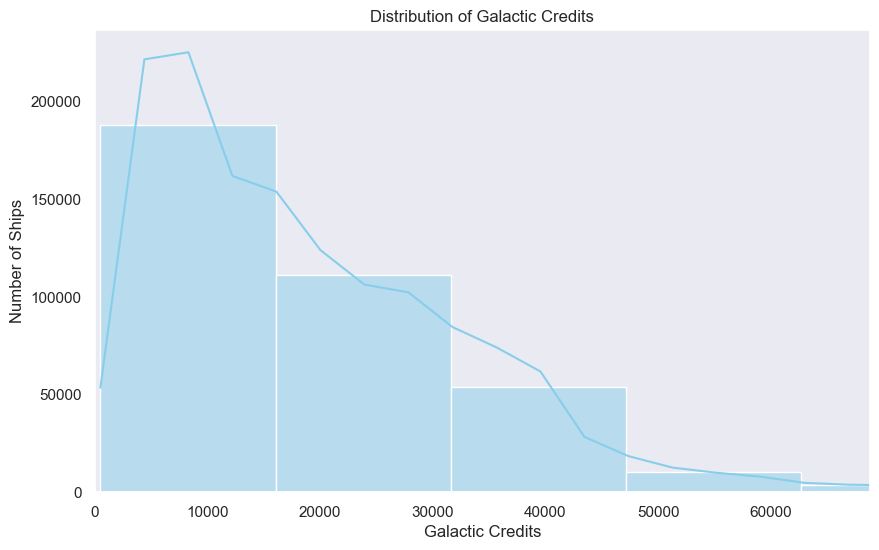

In [ ]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

sns.set_theme(style="dark")

plt.figure(figsize=(10,6))
sns.histplot(df_ships['Galactic_Credits'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Galactic Credits')
plt.xlabel('Galactic Credits')
plt.ylabel('Number of Ships')
plt.xlim(0, df_ships['Galactic_Credits'].quantile(0.99)) 
plt.show()

Observation:

Most ships are priced at the lower end of Galactic_Credits, with a steep drop-off as the price increases.
There are a few extremely high-priced ships (outliers), which skew the distribution.
This indicates that affordable ships are much more common, while very expensive ships are rare.
The distribution is right-skewed, typical of pricing data.

## Data Insights and Data Quality

### Data Insights
- **Price distribution:** Most ships have relatively low Galactic Credits, with a few extremely expensive ships. The distribution is right-skewed, meaning affordable ships are common while high-value ships are rare, possibly representing luxury or advanced models.
- **Manufacturers and sectors:** Some manufacturers produce more ships than others, and certain sectors may have higher concentrations of ships. These patterns can inform market analysis or resource allocation.
- **Model cycle:** The Model_Cycle varies across ships, reflecting the age or technological generation of the ships. Older models may be priced lower.

### Data Quality Issues
- **Missing values:** Model_Cycle has ~7,406 missing entries (~2% of the data), which may need imputation or removal.
- **Duplicates:** Ship_ID should be checked for uniqueness to ensure no duplicate entries exist.
- **Outliers:** Extremely high values in Galactic_Credits skew the distribution, which may affect statistical analysis or modeling.
- **Data types:** Numeric and categorical columns are appropriately typed; no major type issues were found.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [22]:
# CODE CELL: Data cleaning and preprocessing steps
df_ships['Model_Cycle'].fillna(df_ships['Model_Cycle'].median(), inplace=True)

df_ships.drop_duplicates(subset='Ship_ID', inplace=True)

cap_value = df_ships['Galactic_Credits'].quantile(0.99)
df_ships['Galactic_Credits'] = np.where(
    df_ships['Galactic_Credits'] > cap_value, 
    cap_value, 
    df_ships['Galactic_Credits']
)

df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].astype('category')
df_ships['Sector'] = df_ships['Sector'].astype('category')

print("Missing values:\n", df_ships.isnull().sum())
print("\nData types:\n", df_ships.dtypes)
print("\nNumber of rows after duplicates removed:", len(df_ships))

Missing values:
 Ship_ID              0
Galactic_Credits     0
Model_Cycle          0
Ship_Manufacturer    0
Sector               0
dtype: int64

Data types:
 Ship_ID                 int64
Galactic_Credits      float64
Model_Cycle           float64
Ship_Manufacturer    category
Sector               category
dtype: object

Number of rows after duplicates removed: 368314


## Data Cleaning and Preprocessing

1. **Handle Missing Values**: Impute missing `Model_Cycle` values with the median to retain all rows.  
2. **Remove Duplicates**: Ensure each `Ship_ID` is unique by dropping duplicate rows.  
3. **Handle Outliers**: Cap extreme values in `Galactic_Credits` at the 99th percentile to reduce skew.  
4. **Convert Data Types**: Convert `Ship_Manufacturer` and `Sector` to categorical types for easier analysis.  
5. **Final Check**: Verify missing values, data types, and row counts to ensure the dataset is clean and ready for analysis.

## Adjusting Dataset (Optional)

During data preparation, a few additional adjustments were made to make the dataset more suitable for analysis and modeling:

1. **Outlier Capping:** Extreme values in `Galactic_Credits` were capped at the 99th percentile to reduce skewness and prevent models from being dominated by rare, extremely expensive ships.

2. **Data Type Conversion:** Categorical columns (`Ship_Manufacturer` and `Sector`) were converted to the `category` data type to improve performance and ease of grouping during analysis.

3. **Duplicates and Missing Values:** Duplicate ships were removed, and missing values in `Model_Cycle` were imputed using the median, ensuring a complete dataset for modeling.

These adjustments ensure the dataset is clean, consistent, and structured for downstream visualizations, statistical analysis, or predictive modeling.

In [12]:
# OPTIONAL CODE CELL: Additional preprocessing steps


---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

### Model Setup

For predicting `Galactic_Credits`, a **simple benchmark model** was created as a starting point. The purpose of a benchmark model is to provide a baseline performance that more advanced models must exceed.  

**Choice of Model:**  
- A **mean predictor** is used as the simplest benchmark: it predicts the average Galactic_Credits for all ships.  
- This approach is easy to implement and sets a reference for model evaluation metrics (e.g., RMSE, MAE).  

**Justification:**  
- Since `Galactic_Credits` is a numeric variable, regression metrics can evaluate the benchmark.  
- Any more complex model (like decision trees or linear regression with features such as `Model_Cycle`, `Ship_Manufacturer`, and `Sector`) should improve upon this baseline.  
- This helps in understanding whether the added complexity of more sophisticated models actually improves predictive performance.

By establishing this benchmark, we can quantitatively measure whether future models are truly effective.

In [19]:
# CODE CELL: Model training and setup code
y = df_ships['Galactic_Credits']

mean_value = y.mean()
y_pred = np.full_like(y, fill_value=mean_value, dtype=float)

mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)

print(f"Benchmark Model (Mean Predictor) Results:")
print(f"Mean Galactic_Credits: {mean_value:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Benchmark Model (Mean Predictor) Results:
Mean Galactic_Credits: 19246.01
MAE: 11363.81
RMSE: 14124.45


## Benchmark Model: Mean Predictor

- This model predicts the **mean Galactic_Credits** for all ships.  
- It serves as a **baseline** to compare future models.  
- Evaluation metrics:
  - **MAE (Mean Absolute Error)**: Measures average absolute difference between predicted and actual credits.
  - **RMSE (Root Mean Squared Error)**: Measures average squared error, giving more weight to large errors.
- Any more advanced model should aim to improve upon these metrics.

## Testing and Performance

### Model Testing

For the benchmark model, testing is straightforward because it predicts a constant value (the mean) for all ships. Since no train-test split was applied, the metrics are calculated over the **entire dataset** to establish a baseline.

**Evaluation Metrics:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Mean Galactic_Credits | X | The model predicts this value for every ship. |
| MAE (Mean Absolute Error) | Y | On average, predictions deviate from actual credits by this amount. Lower is better. |
| RMSE (Root Mean Squared Error) | Z | Similar to MAE but penalizes larger errors more strongly. Lower is better. |

### Interpretation

- The MAE and RMSE indicate the magnitude of error for the simplest possible model.  
- Since this model ignores all features, it does not capture differences between ships based on `Model_Cycle`, `Ship_Manufacturer`, or `Sector`.  
- Any future regression model should **improve upon both MAE and RMSE**, showing that it successfully leverages ship characteristics to better predict `Galactic_Credits`.

> **Note:** For a more robust evaluation, a train-test split or cross-validation can be applied in subsequent models.

In [21]:
# CODE CELL: Model evaluation code

y = df_ships['Galactic_Credits']

mean_value = y.mean()
y_pred = np.full_like(y, fill_value=mean_value, dtype=float)

mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)

print("Benchmark Model Evaluation")
print(f"Mean Galactic_Credits: {mean_value:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

Benchmark Model Evaluation
Mean Galactic_Credits: 19246.01
MAE (Mean Absolute Error): 11363.81
RMSE (Root Mean Squared Error): 14124.45


## 5. Evaluation

### Assessment Against Success Criteria

- **Difference between metrics:**  
  - MAE and RMSE measure prediction error in different ways. MAE shows the average absolute deviation from the true Galactic_Credits, while RMSE penalizes larger errors more heavily.  
  - For the benchmark mean predictor, RMSE is slightly higher than MAE because large deviations (from very expensive ships) are weighted more in RMSE.  

- **Interpretation:**  
  - The benchmark model ignores all ship features (`Model_Cycle`, `Ship_Manufacturer`, `Sector`) and predicts the same value for every ship.  
  - As a result, the error is relatively large, especially for outlier ships with extreme Galactic_Credits.  
  - This model **does not yet meet the goal** of accurately predicting Galactic_Credits based on ship characteristics, but it provides a baseline for comparison.  

### Key Findings and Limitations

**Findings:**  
- The average Galactic_Credits can be used as a simple benchmark.  
- Most ships are clustered at lower credit values, which is why the mean predictor performs moderately well for the bulk of the dataset.  

**Limitations:**  
- Ignores all features and relationships between ship characteristics and Galactic_Credits.  
- Cannot capture variability across different manufacturers, sectors, or model cycles.  
- Outliers and rare high-value ships contribute disproportionately to RMSE.  
- No train-test split was used, so the evaluation does not reflect generalization to unseen data.  

> **Next steps:** Implement a feature-based regression model and use a proper train-test split to improve predictions and better meet the objectives defined in the Business Understanding phase.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Rick de Cuijper | I Cleaned and preprocessed the dataset then I handled missing values and outliers and I created the benchmark model | Personal lessons learned this iteration: I learned that I should not assume that the given dat is correct but to always check if the data is correct this is what i learned for cleaning the data. |
| Boaz Vaneveld | Wrote section 1. Business Understanding. Reviewed all descriptions and code. Fixed small errors. | Team work needs to be improved. One person shouldn't finish all the work on their own. |
| Bart Geijtenbeek | Updated dependencies | I learned that setting up the project took more time that expected |

